# NB02 — Bonferroni Survivors: Deep Dive

NB01 identified **6 drugs** whose pharmacogenomically-annotated adverse events show
disproportionately stronger FAERS signals than their unannotated AEs, surviving
Bonferroni correction across 147 tested drugs.

This notebook traces the mechanistic chain for each hit:
**variant → PharmGKB-predicted phenotype → observed FAERS ROR for that AE vs all others for that drug.**

Rituximab gets a full section (the headline hit). The remaining five are covered
with enough detail to assess biological plausibility.

All statistics computed in NB01; this notebook is interpretive and visual.

In [1]:
import sys, os
from pathlib import Path
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

signals = pd.read_csv('data/signals_pgx_drugs.csv')
matched = pd.read_csv('data/enrichment_results.csv')
test_results = pd.read_csv('data/enrichment_test_results.csv')

BONF_DRUGS = ['BEVACIZUMAB', 'RITUXIMAB', 'LETROZOLE', 'LEFLUNOMIDE', 'TOCILIZUMAB', 'ANASTROZOLE']

bonf = (test_results[test_results['significant_bonferroni']]
        .set_index('DRUG').loc[BONF_DRUGS].reset_index())

print(f'Signals: {len(signals):,} rows | {signals["DRUG"].nunique()} drugs')
print(f'Matched pairs: {len(matched):,}')
print(f'Bonferroni survivors: {len(bonf)}')

Signals: 58,368 rows | 252 drugs
Matched pairs: 2,163
Bonferroni survivors: 6


In [2]:
# Summary table of the 6 Bonferroni survivors
display_cols = [
    'DRUG', 'n_pgx_annotated_aes', 'n_unannotated_aes',
    'median_ror_annotated', 'median_ror_unannotated',
    'ror_fold_enrichment', 'p_value', 'p_value_fdr_bh', 'p_value_bonferroni'
]
summary = bonf[display_cols].copy()
summary.columns = [
    'Drug', 'PGx AEs (n)', 'Unannotated AEs (n)',
    'Median ROR (PGx)', 'Median ROR (other)',
    'Fold enrichment', 'p (raw)', 'q (BH-FDR)', 'p (Bonferroni)'
]
summary = summary.sort_values('Fold enrichment', ascending=False)
print('Bonferroni-surviving drugs — ordered by fold enrichment:')
print(summary.to_string(index=False))

Bonferroni-surviving drugs — ordered by fold enrichment:
       Drug  PGx AEs (n)  Unannotated AEs (n)  Median ROR (PGx)  Median ROR (other)  Fold enrichment  p (raw)  q (BH-FDR)  p (Bonferroni)
  LETROZOLE           16                  521             36.76                5.92             6.21   0.0000      0.0000          0.0000
ANASTROZOLE           15                  431             32.95                6.69             4.92   0.0003      0.0074          0.0441
LEFLUNOMIDE           10                  466             36.11                8.23             4.39   0.0002      0.0074          0.0294
TOCILIZUMAB            9                  580             12.69                3.84             3.30   0.0003      0.0074          0.0441
BEVACIZUMAB           34                  786             19.40                6.90             2.81   0.0000      0.0000          0.0000
  RITUXIMAB           63                 1280              8.84                4.24             2.09   0.0000      

## 1. Signal distributions: annotated vs unannotated AEs

For each Bonferroni-surviving drug, we compare the full ROR distribution of
pharmacogenomically-annotated AEs (PharmGKB match confidence ≥ 0.5) against
all other AEs for that drug in FAERS. The Mann-Whitney U result from NB01
tests stochastic dominance between these two distributions.

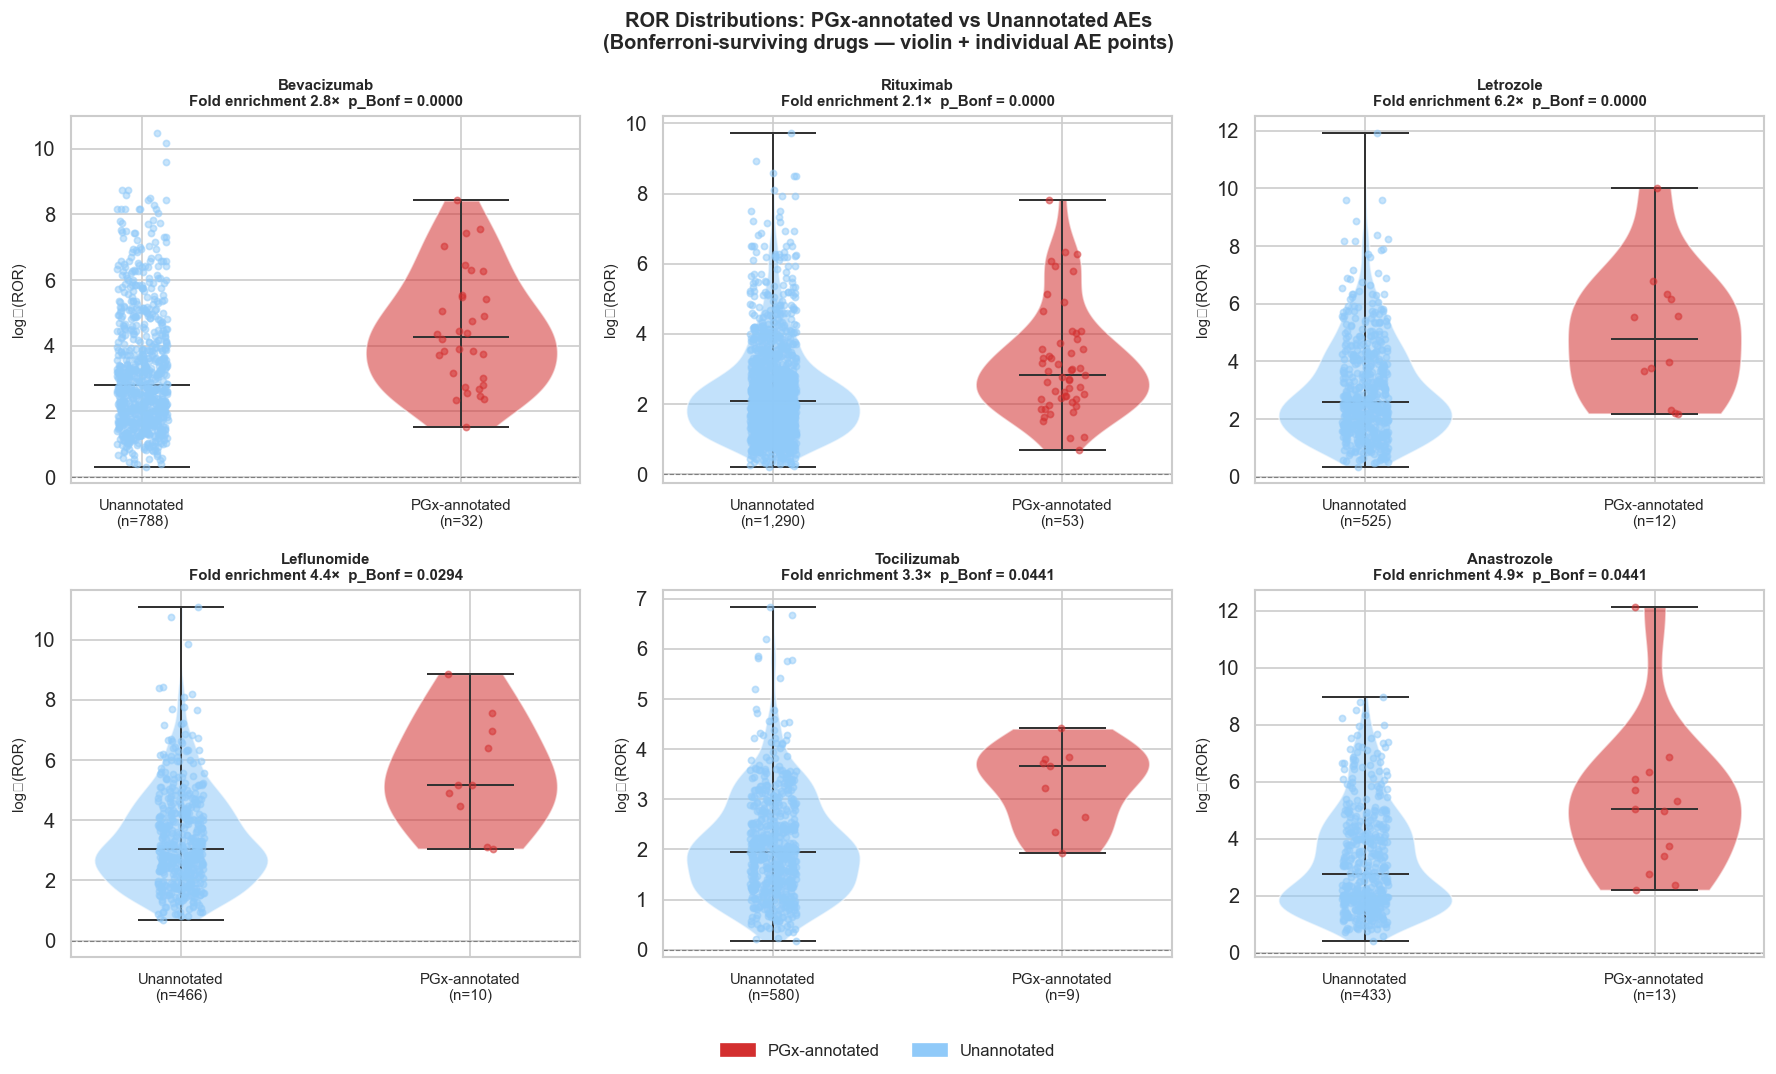

In [3]:
def get_drug_rors(drug, min_conf=0.5):
    """Return two Series: log2(ROR) for annotated and unannotated AEs."""
    all_aes = signals[signals['DRUG'] == drug].copy()
    ann_pts  = set(matched[(matched['DRUG'] == drug) &
                            (matched['MATCH_CONFIDENCE'] >= min_conf)]['PT'])
    annotated   = np.log2(all_aes[all_aes['PT'].isin(ann_pts)]['ROR'].clip(0.1))
    unannotated = np.log2(all_aes[~all_aes['PT'].isin(ann_pts)]['ROR'].clip(0.1))
    return annotated, unannotated


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

COLORS = {'PGx-annotated': '#d32f2f', 'Unannotated': '#90caf9'}

for ax, drug in zip(axes, BONF_DRUGS):
    ann, unann = get_drug_rors(drug)
    row = bonf[bonf['DRUG'] == drug].iloc[0]

    # Violin + strip
    parts = ax.violinplot(
        [unann.dropna().values, ann.dropna().values],
        positions=[0, 1], showmedians=True, widths=0.6
    )
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor([COLORS['Unannotated'], COLORS['PGx-annotated']][i])
        pc.set_alpha(0.55)
    for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        parts[part].set_color('#333')
        parts[part].set_linewidth(1.2)

    np.random.seed(42)
    for i, (vals, col) in enumerate([(unann, COLORS['Unannotated']),
                                      (ann, COLORS['PGx-annotated'])]):
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter(i + jitter, vals, alpha=0.5, s=14, color=col, zorder=3)

    ax.axhline(0, color='black', lw=0.7, linestyle='--', alpha=0.4)  # ROR=1 line
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Unannotated\n(n={:,})'.format(len(unann)),
                         'PGx-annotated\n(n={})'.format(len(ann))], fontsize=9)
    ax.set_ylabel('log₂(ROR)', fontsize=9)
    ax.set_title(
        f'{drug.title()}\n'
        f'Fold enrichment {row["ror_fold_enrichment"]:.1f}×  '
        f'p_Bonf = {row["p_value_bonferroni"]:.4f}',
        fontsize=9, fontweight='bold'
    )

plt.suptitle(
    'ROR Distributions: PGx-annotated vs Unannotated AEs\n'
    '(Bonferroni-surviving drugs — violin + individual AE points)',
    fontsize=12, fontweight='bold'
)
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=10, frameon=False)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(FIGURES_DIR / 'nb02_01_overview_panel.png')
plt.show()

## 2. Rituximab

Rituximab is a chimeric IgG1κ anti-CD20 monoclonal antibody. It depletes
B-cells by three mechanisms: complement-dependent cytotoxicity (CDC),
antibody-dependent cellular cytotoxicity (ADCC), and direct apoptosis induction.
ADCC is the dominant mechanism for B-cell depletion in lymphoma.

**FCGR3A (FcγRIIIA / CD16a)** is the Fc receptor expressed on NK cells and
macrophages that binds the Fc domain of rituximab, initiating ADCC. The
rs396991 V158F polymorphism creates two alleles:
- **158V (valine):** higher affinity for IgG1 Fc → stronger ADCC → better rituximab response
- **158F (phenylalanine):** lower affinity → reduced ADCC → attenuated response

Multiple randomized trials in DLBCL (R-CHOP regimen) and follicular lymphoma
confirmed that FCGR3A-158V homozygotes achieve significantly higher rates of
molecular remission. The same variant predicts response in rituximab-treated
neuromyelitis optica spectrum disorder (NMO).

**GSTA1** (glutathione S-transferase alpha-1) variants affect intracellular
detoxification in lymphoma cells; associated with rituximab treatment response
in DLBCL in candidate-gene studies (PharmGKB evidence level 3).

**FAERS interpretation:** The enrichment signal means that FAERS spontaneous
reports for rituximab are disproportionately capturing the pharmacogenomically-
predicted failure modes — disease progression, lymphoma recurrence, and NMO
exacerbation — rather than idiosyncratic events uncorrelated with known biology.

In [4]:
rit = matched[(matched['DRUG'] == 'RITUXIMAB') & (matched['MATCH_CONFIDENCE'] >= 0.5)].copy()
rit_display = rit[['PT', 'n_reports', 'ROR', 'EVIDENCE_LEVEL', 'PGX_GENE', 'PGX_PHENOTYPE', 'MATCH_CONFIDENCE']].copy()
rit_display.columns = ['MedDRA PT', 'Reports (n)', 'ROR', 'Evidence', 'Gene', 'PharmGKB Phenotype', 'Match conf.']
rit_display['ROR'] = rit_display['ROR'].round(1)
rit_display = rit_display.sort_values('ROR', ascending=False)
print(f'Rituximab matched pairs (confidence ≥ 0.5): {len(rit_display)}')
print()
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 30)
print(rit_display.to_string(index=False))

Rituximab matched pairs (confidence ≥ 0.5): 53

                                               MedDRA PT  Reports (n)   ROR Evidence   Gene                        PharmGKB Phenotype  Match conf.
                                 LYMPHOMA TRANSFORMATION           82 227.4        3  ABCB1                      NON HODGKIN LYMPHOMA         0.50
                 DIFFUSE LARGE B-CELL LYMPHOMA RECURRENT          239  81.3        3  GSTA1             LYMPHOMA LARGE B CELL DIFFUSE         0.85
                 CHRONIC LYMPHOCYTIC LEUKAEMIA RECURRENT           63  76.8        3 CXCL12       LEUKEMIA LYMPHOCYTIC CHRONIC B CELL         0.57
                         MANTLE CELL LYMPHOMA REFRACTORY            5  67.6        3  GSTA1             LYMPHOMA LARGE B CELL DIFFUSE         0.57
            CHRONIC LYMPHOCYTIC LEUKAEMIA TRANSFORMATION            8  60.8        3 CXCL12       LEUKEMIA LYMPHOCYTIC CHRONIC B CELL         0.57
                                     FOLLICULAR LYMPHOMA          112 

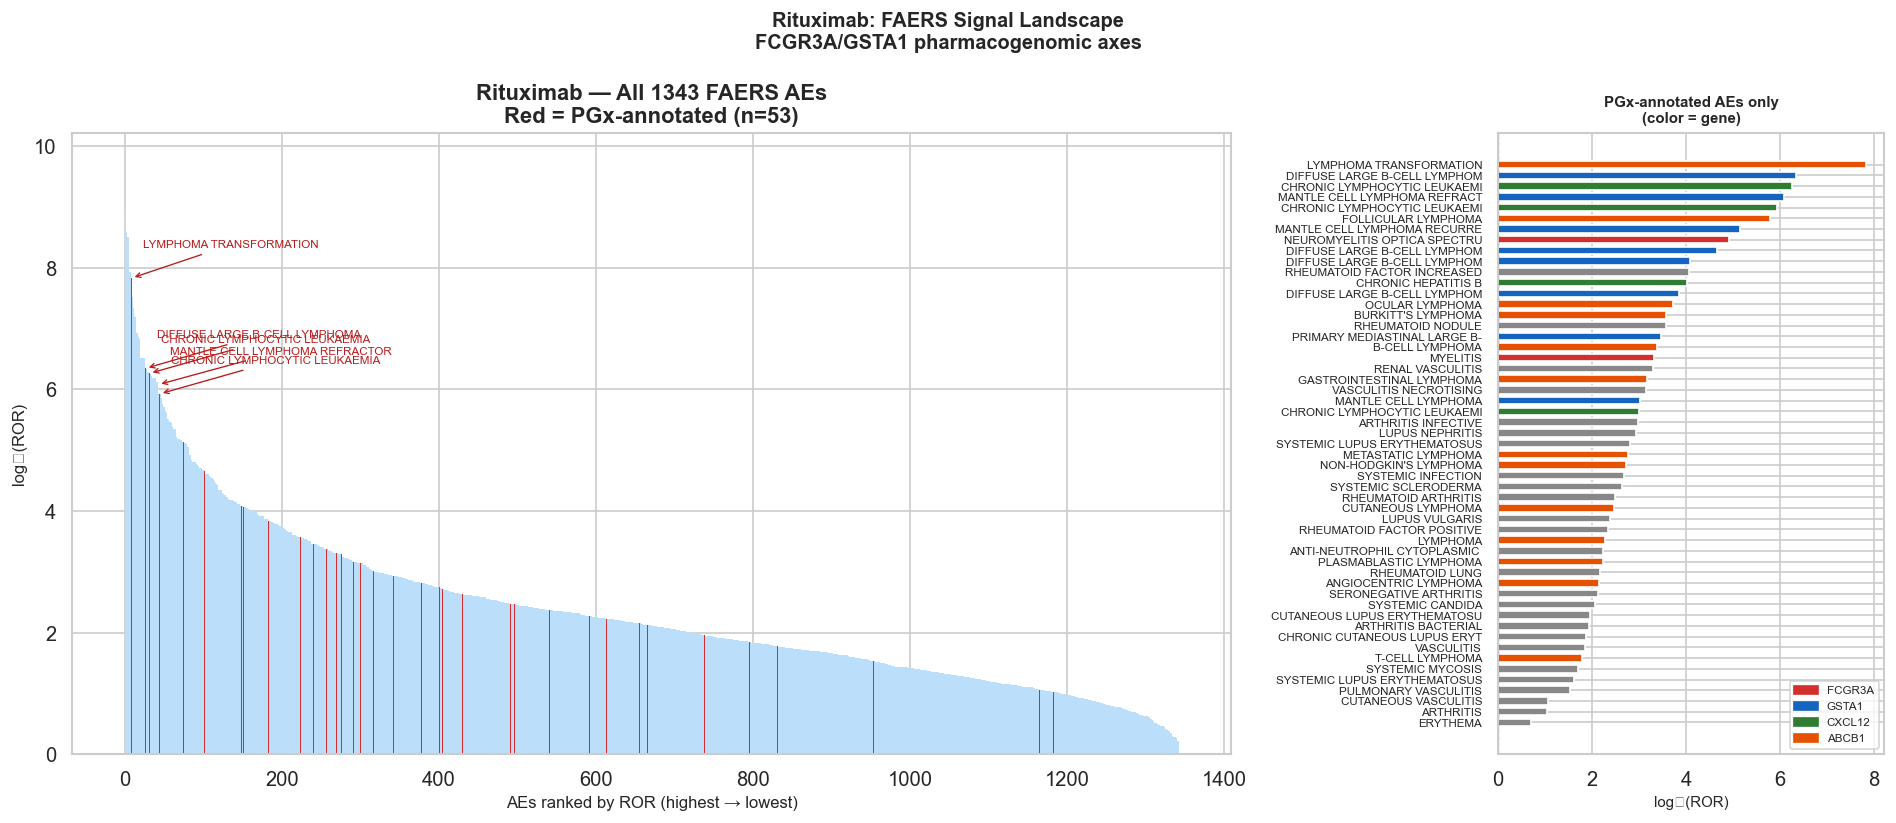

Annotated AEs — median log2(ROR): 2.82 (7.0×)
Unannotated AEs — median log2(ROR): 2.09 (4.3×)
Mann-Whitney U = 46183, p = 7.268e-06


In [5]:
rit_all = signals[signals['DRUG'] == 'RITUXIMAB'].copy()
ann_pts = set(matched[(matched['DRUG'] == 'RITUXIMAB') &
                       (matched['MATCH_CONFIDENCE'] >= 0.5)]['PT'])
rit_all['annotated'] = rit_all['PT'].isin(ann_pts)
rit_all['log2_ror'] = np.log2(rit_all['ROR'].clip(0.1))
rit_all = rit_all.sort_values('log2_ror', ascending=False).reset_index(drop=True)

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(16, 7),
                                        gridspec_kw={'width_ratios': [3, 1]})

# Waterfall — all AEs
colors_wf = ['#d32f2f' if a else '#bbdefb' for a in rit_all['annotated']]
ax_main.bar(range(len(rit_all)), rit_all['log2_ror'], color=colors_wf,
             width=1.0, linewidth=0)
ax_main.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax_main.set_xlabel('AEs ranked by ROR (highest → lowest)', fontsize=10)
ax_main.set_ylabel('log₂(ROR)', fontsize=10)
ax_main.set_title(
    f'Rituximab — All {len(rit_all)} FAERS AEs\nRed = PGx-annotated (n={rit_all["annotated"].sum()})',
    fontweight='bold'
)

# Annotate top annotated hits
top_ann = rit_all[rit_all['annotated']].head(5)
for _, row in top_ann.iterrows():
    ax_main.annotate(
        row['PT'][:30], xy=(row.name, row['log2_ror']),
        xytext=(row.name + 15, row['log2_ror'] + 0.5),
        fontsize=7, color='#b71c1c',
        arrowprops=dict(arrowstyle='->', color='#b71c1c', lw=0.8)
    )

# Right panel — PGx-annotated only, gene color-coded
gene_colors = {'FCGR3A': '#d32f2f', 'GSTA1': '#1565c0', 'CXCL12': '#2e7d32',
               'ABCB1': '#e65100', 'UGT1A1': '#6a1b9a'}
rit_ann = rit_all[rit_all['annotated']].copy()
rit_ann_gene = rit_ann.merge(
    matched[(matched['DRUG'] == 'RITUXIMAB') & (matched['MATCH_CONFIDENCE'] >= 0.5)][['PT', 'PGX_GENE', 'ROR']]
    .drop_duplicates('PT'),
    on='PT', how='left', suffixes=('', '_m')
)
rit_ann_gene['gene_color'] = rit_ann_gene['PGX_GENE'].map(gene_colors).fillna('#888')
rit_ann_gene = rit_ann_gene.sort_values('log2_ror', ascending=True).reset_index(drop=True)

ax_zoom.barh(range(len(rit_ann_gene)), rit_ann_gene['log2_ror'],
              color=rit_ann_gene['gene_color'], height=0.7)
ax_zoom.set_yticks(range(len(rit_ann_gene)))
ax_zoom.set_yticklabels(
    [f"{row['PT'][:28]}" for _, row in rit_ann_gene.iterrows()],
    fontsize=7
)
ax_zoom.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax_zoom.set_xlabel('log₂(ROR)', fontsize=9)
ax_zoom.set_title('PGx-annotated AEs only\n(color = gene)', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in gene_colors.items()
                  if k in rit_ann_gene['PGX_GENE'].values]
ax_zoom.legend(handles=legend_patches, fontsize=7, loc='lower right')

plt.suptitle('Rituximab: FAERS Signal Landscape\nFCGR3A/GSTA1 pharmacogenomic axes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_02_rituximab_waterfall.png')
plt.show()

# Summary stats
ann_rors   = np.log2(rit_all[rit_all['annotated']]['ROR'].clip(0.1))
unann_rors = np.log2(rit_all[~rit_all['annotated']]['ROR'].clip(0.1))
u, p = stats.mannwhitneyu(ann_rors, unann_rors, alternative='greater')
print(f'Annotated AEs — median log2(ROR): {ann_rors.median():.2f} ({2**ann_rors.median():.1f}×)')
print(f'Unannotated AEs — median log2(ROR): {unann_rors.median():.2f} ({2**unann_rors.median():.1f}×)')
print(f'Mann-Whitney U = {u:.0f}, p = {p:.4g}')

## 3. Letrozole and Anastrozole: the aromatase axis

Letrozole and anastrozole are third-generation **aromatase inhibitors** — the
frontline adjuvant therapy for hormone receptor-positive breast cancer in
postmenopausal women. They irreversibly (letrozole) or non-steroidal-reversibly
(anastrozole) inhibit **CYP19A1**, the gene encoding aromatase, which catalyzes
the final step of estrogen biosynthesis from androgens in peripheral tissues.

The pharmacogenomic logic is unusually direct:
- **CYP19A1 encodes the drug's target enzyme.** Variants (including the intron 4
  TTTA repeat polymorphism and rs10046/rs4646) affect constitutive aromatase
  activity, baseline estrogen levels, and the residual estrogen after drug
  treatment.
- Carriers of high-activity CYP19A1 haplotypes have higher baseline estrogen
  and larger tumor estrogen exposure — and may require higher AI doses or show
  more pronounced drug effect.
- **CYP2A6** also metabolizes androgens upstream of aromatase; variants affect
  the androgen substrate pool available for estrogen synthesis.

The 'menopause delayed' FAERS signal for letrozole (ROR = 1,039) captures a
real pharmacology: letrozole drives near-complete estrogen suppression, and
women with high CYP19A1 activity may experience prolonged estrogen dependence
that manifests as paradoxical menopause-delay phenotypes in the AE reporting.

**Anastrozole note:** The PGX_GENE field is NaN in our matched pairs — the
PharmGKB clinical annotations we captured for anastrozole reference breast
neoplasm outcomes without a resolved gene in our extraction. The biological
mechanism is the same as letrozole (same drug class, same CYP19A1 target).
The parallel enrichment signal across both drugs strengthens the finding.

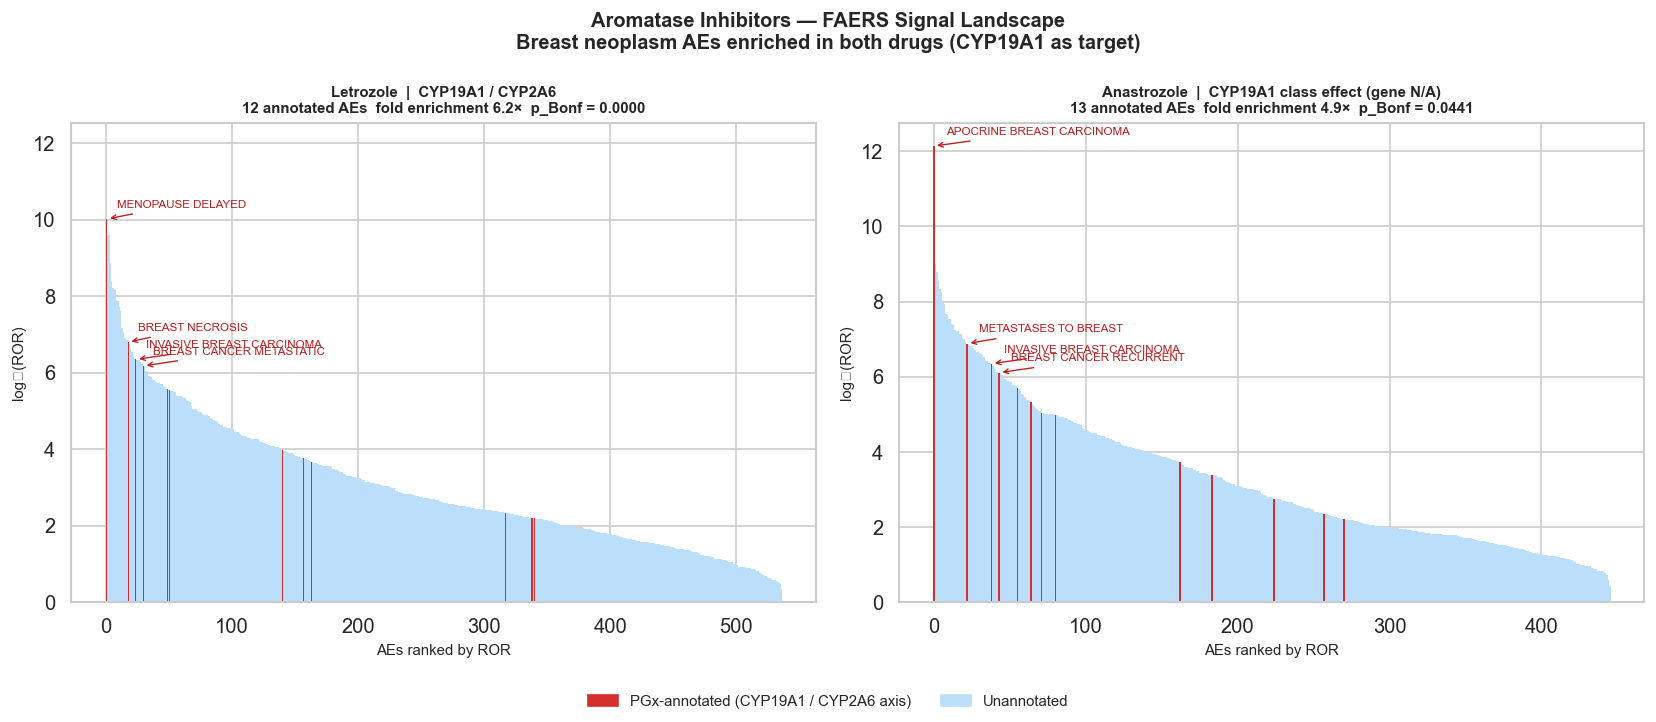


Letrozole PGx-annotated pairs:
                       PT  n_reports         ROR PGX_GENE              PGX_PHENOTYPE EVIDENCE_LEVEL
        MENOPAUSE DELAYED          4 1038.867107  CYP19A1 BREAST NEOPLASMS MENOPAUSE              3
          BREAST NECROSIS          4  111.306207   CYP2A6           BREAST NEOPLASMS              3
INVASIVE BREAST CARCINOMA          7   81.469218   CYP2A6           BREAST NEOPLASMS              3
 BREAST CANCER METASTATIC        116   72.428048   CYP2A6           BREAST NEOPLASMS              3
     METASTASES TO BREAST          3   47.689176   CYP2A6           BREAST NEOPLASMS              3
  BREAST CANCER RECURRENT         28   46.918204   CYP2A6           BREAST NEOPLASMS              3
            BREAST CANCER         80   15.743792   CYP2A6           BREAST NEOPLASMS              3
              BREAST MASS         15   13.611155   CYP2A6           BREAST NEOPLASMS              3
          BREAST DISORDER          4   12.719734   CYP2A6           

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, drug in zip(axes, ['LETROZOLE', 'ANASTROZOLE']):
    drug_sigs = signals[signals['DRUG'] == drug].copy()
    ann_pts = set(matched[(matched['DRUG'] == drug) &
                           (matched['MATCH_CONFIDENCE'] >= 0.5)]['PT'])
    drug_sigs['annotated'] = drug_sigs['PT'].isin(ann_pts)
    drug_sigs['log2_ror']  = np.log2(drug_sigs['ROR'].clip(0.1))
    drug_sigs = drug_sigs.sort_values('log2_ror', ascending=False).reset_index(drop=True)

    colors = ['#d32f2f' if a else '#bbdefb' for a in drug_sigs['annotated']]
    ax.bar(range(len(drug_sigs)), drug_sigs['log2_ror'], color=colors, width=1.0, linewidth=0)
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)

    # Annotate top annotated hits
    for _, row in drug_sigs[drug_sigs['annotated']].head(4).iterrows():
        ax.annotate(
            row['PT'][:25], xy=(row.name, row['log2_ror']),
            xytext=(row.name + 8, row['log2_ror'] + 0.3),
            fontsize=7, color='#b71c1c',
            arrowprops=dict(arrowstyle='->', color='#b71c1c', lw=0.8)
        )

    row_stat = bonf[bonf['DRUG'] == drug].iloc[0]
    pgx_label = 'CYP19A1 / CYP2A6' if drug == 'LETROZOLE' else 'CYP19A1 class effect (gene N/A)'
    ax.set_xlabel('AEs ranked by ROR', fontsize=9)
    ax.set_ylabel('log₂(ROR)', fontsize=9)
    ax.set_title(
        f'{drug.title()}  |  {pgx_label}\n'
        f'{drug_sigs["annotated"].sum()} annotated AEs  '
        f'fold enrichment {row_stat["ror_fold_enrichment"]:.1f}×  '
        f'p_Bonf = {row_stat["p_value_bonferroni"]:.4f}',
        fontsize=9, fontweight='bold'
    )

patches = [
    mpatches.Patch(color='#d32f2f', label='PGx-annotated (CYP19A1 / CYP2A6 axis)'),
    mpatches.Patch(color='#bbdefb', label='Unannotated')
]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9, frameon=False)
plt.suptitle(
    'Aromatase Inhibitors — FAERS Signal Landscape\n'
    'Breast neoplasm AEs enriched in both drugs (CYP19A1 as target)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIGURES_DIR / 'nb02_03_aromatase_waterfall.png')
plt.show()

# Print letrozole annotated pairs
let_ann = matched[(matched['DRUG'] == 'LETROZOLE') & (matched['MATCH_CONFIDENCE'] >= 0.5)]
print('\nLetrozole PGx-annotated pairs:')
print(let_ann[['PT', 'n_reports', 'ROR', 'PGX_GENE', 'PGX_PHENOTYPE', 'EVIDENCE_LEVEL']]
      .sort_values('ROR', ascending=False).to_string(index=False))

## 4. Bevacizumab: VEGFA as target and susceptibility locus

Bevacizumab (Avastin) is a humanized IgG1 monoclonal antibody that binds
**VEGF-A** (vascular endothelial growth factor A), blocking its interaction with
VEGFR-1/2 and suppressing tumor angiogenesis. It is approved for colorectal,
lung, glioblastoma, renal cell, and ovarian cancers, and for neovascular
age-related macular degeneration (AMD).

**VEGFA** is simultaneously the drug's target and a susceptibility gene:
- VEGFA variants (rs2010963, rs1570360) affect baseline VEGF expression,
  angiogenic drive, and response to anti-VEGF therapy
- In AMD, VEGFA genotype predicts both disease risk and ranibizumab/bevacizumab
  treatment response (multiple replication cohorts)
- The hypertension AE signal reflects a class effect of VEGF pathway inhibition
  (VEGF normally promotes NO-mediated vasodilation); **HSP90AB1** variants affect
  VEGFR2 stability and may modulate hypertension severity
- **SHMT1** (serine hydroxymethyltransferase 1) variants influence colorectal
  cancer response to bevacizumab-containing chemotherapy regimens

The enrichment is driven by AMD-related signals (macular degeneration,
macular thickening) and hypertension variants in the annotated group — both
representing known VEGF-pathway biology captured in FAERS.

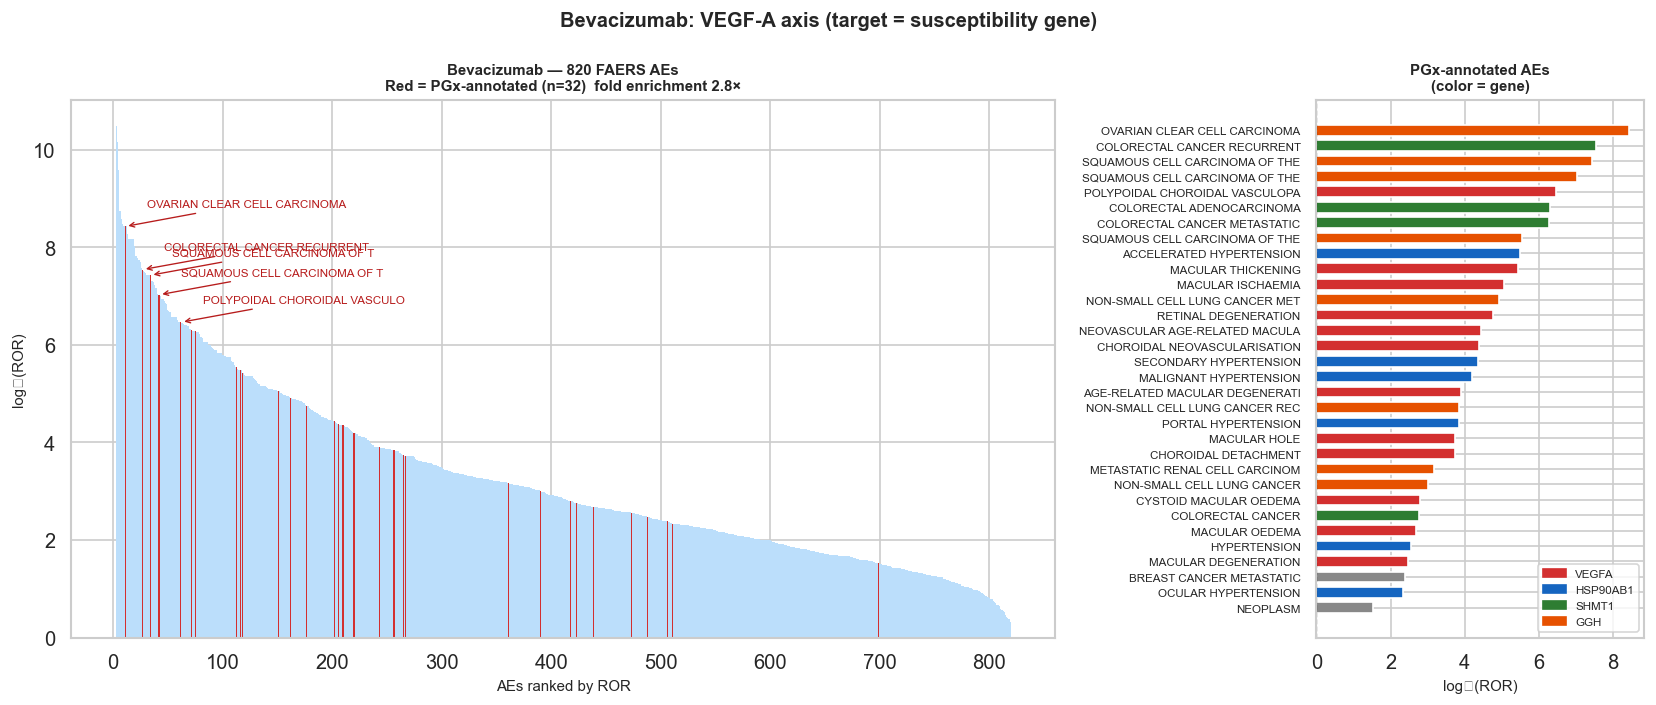

In [7]:
fig, (ax_wf, ax_ann) = plt.subplots(1, 2, figsize=(14, 6),
                                     gridspec_kw={'width_ratios': [3, 1]})

drug = 'BEVACIZUMAB'
drug_sigs = signals[signals['DRUG'] == drug].copy()
ann_pts = set(matched[(matched['DRUG'] == drug) &
                       (matched['MATCH_CONFIDENCE'] >= 0.5)]['PT'])
drug_sigs['annotated'] = drug_sigs['PT'].isin(ann_pts)
drug_sigs['log2_ror']  = np.log2(drug_sigs['ROR'].clip(0.1))
drug_sigs = drug_sigs.sort_values('log2_ror', ascending=False).reset_index(drop=True)

colors = ['#d32f2f' if a else '#bbdefb' for a in drug_sigs['annotated']]
ax_wf.bar(range(len(drug_sigs)), drug_sigs['log2_ror'], color=colors, width=1.0, linewidth=0)
ax_wf.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)

for _, row in drug_sigs[drug_sigs['annotated']].head(5).iterrows():
    ax_wf.annotate(
        row['PT'][:28], xy=(row.name, row['log2_ror']),
        xytext=(row.name + 20, row['log2_ror'] + 0.4),
        fontsize=7, color='#b71c1c',
        arrowprops=dict(arrowstyle='->', color='#b71c1c', lw=0.8)
    )

row_stat = bonf[bonf['DRUG'] == drug].iloc[0]
ax_wf.set_xlabel('AEs ranked by ROR', fontsize=9)
ax_wf.set_ylabel('log₂(ROR)', fontsize=9)
ax_wf.set_title(
    f'Bevacizumab — {len(drug_sigs)} FAERS AEs\n'
    f'Red = PGx-annotated (n={drug_sigs["annotated"].sum()})  '
    f'fold enrichment {row_stat["ror_fold_enrichment"]:.1f}×',
    fontsize=9, fontweight='bold'
)

# Right panel: annotated AEs gene-colored
bev_ann = matched[(matched['DRUG'] == drug) & (matched['MATCH_CONFIDENCE'] >= 0.5)].copy()
bev_ann['log2_ror'] = np.log2(bev_ann['ROR'].clip(0.1))
bev_ann = bev_ann.sort_values('log2_ror', ascending=True).reset_index(drop=True)

gene_colors_bev = {'VEGFA': '#d32f2f', 'HSP90AB1': '#1565c0', 'SHMT1': '#2e7d32', 'GGH': '#e65100'}
bev_ann['gc'] = bev_ann['PGX_GENE'].map(gene_colors_bev).fillna('#888')

ax_ann.barh(range(len(bev_ann)), bev_ann['log2_ror'], color=bev_ann['gc'], height=0.7)
ax_ann.set_yticks(range(len(bev_ann)))
ax_ann.set_yticklabels([row['PT'][:30] for _, row in bev_ann.iterrows()], fontsize=7)
ax_ann.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax_ann.set_xlabel('log₂(ROR)', fontsize=9)
ax_ann.set_title('PGx-annotated AEs\n(color = gene)', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in gene_colors_bev.items()
                  if k in bev_ann['PGX_GENE'].values]
ax_ann.legend(handles=legend_patches, fontsize=7, loc='lower right')

plt.suptitle('Bevacizumab: VEGF-A axis (target = susceptibility gene)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb02_04_bevacizumab_waterfall.png')
plt.show()

## 5. Leflunomide, Tocilizumab, and a cross-drug FCGR3A note

**Leflunomide** is a DHODH (dihydroorotate dehydrogenase) inhibitor used in
rheumatoid arthritis. **ESR1** (estrogen receptor alpha) variants influence RA
susceptibility and disease severity — estrogen modulates autoimmune signaling,
and ESR1 haplotypes track with joint damage progression and treatment response.
The enriched FAERS signals are RA phenotypes (rheumatoid arthritis itself,
rheumatoid nodule, rheumatoid lung, seronegative arthritis) — the drug's
indication phenotype, concentrated in the annotated group.

**Tocilizumab** is a humanized anti-IL-6 receptor IgG1 monoclonal antibody
used for RA, giant cell arteritis, and cytokine release syndrome.
Like rituximab, it is an IgG1 mAb, so **FCGR3A** again mediates ADCC.
The same V158F polymorphism that predicts rituximab response also affects
the Fc-mediated component of tocilizumab activity.

**Cross-drug note:** FCGR3A appearing in both rituximab and tocilizumab is
mechanistically expected — FCGR3A is the universal Fc receptor for IgG1 mAbs.
The convergence across two independent drugs strengthens confidence that
the FAERS enrichment is detecting real Fc-receptor biology rather than noise.

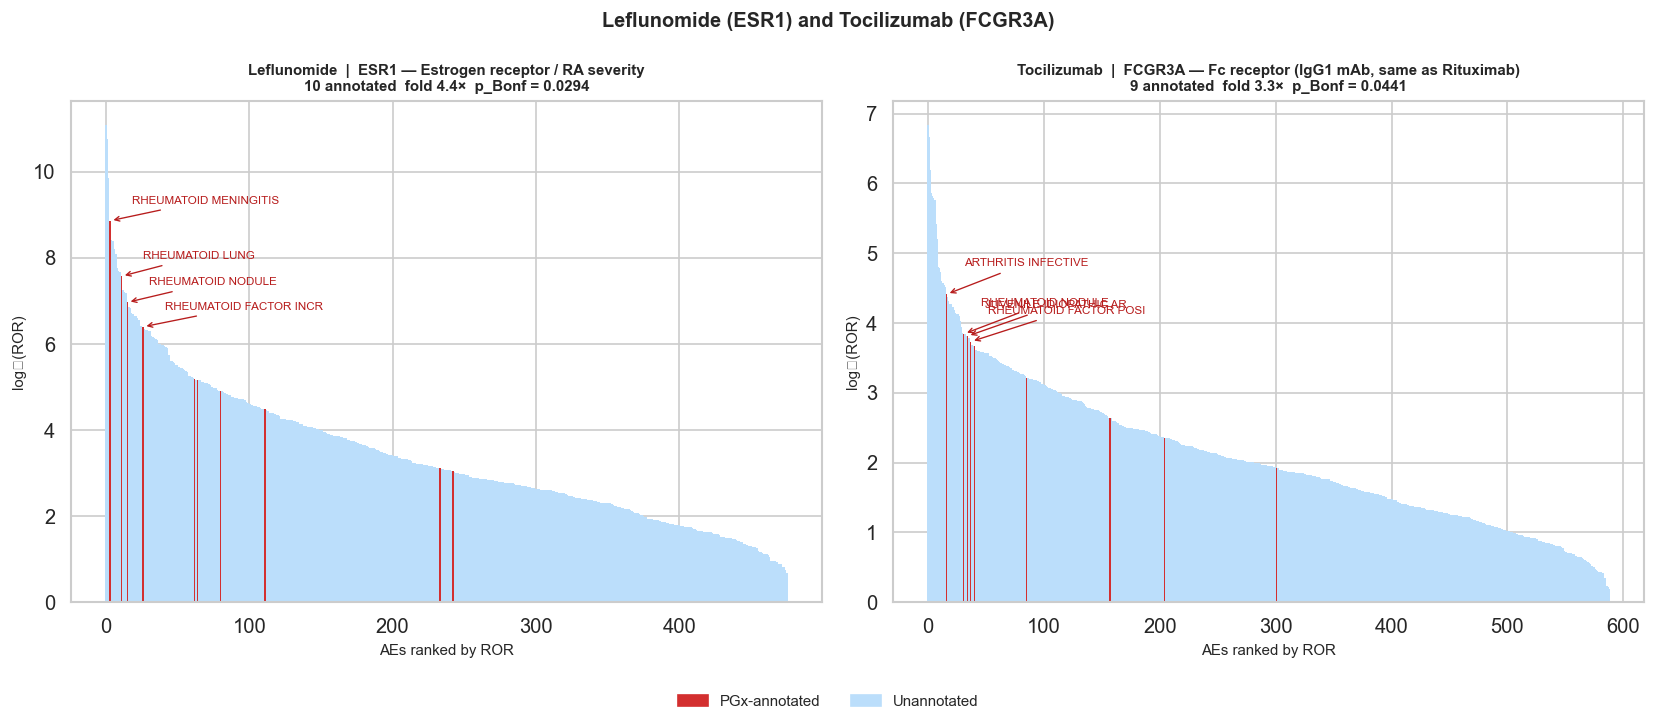

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

drug_info = {
    'LEFLUNOMIDE': 'ESR1 — Estrogen receptor / RA severity',
    'TOCILIZUMAB': 'FCGR3A — Fc receptor (IgG1 mAb, same as Rituximab)',
}

for ax, (drug, label) in zip(axes, drug_info.items()):
    drug_sigs = signals[signals['DRUG'] == drug].copy()
    ann_pts = set(matched[(matched['DRUG'] == drug) &
                           (matched['MATCH_CONFIDENCE'] >= 0.5)]['PT'])
    drug_sigs['annotated'] = drug_sigs['PT'].isin(ann_pts)
    drug_sigs['log2_ror']  = np.log2(drug_sigs['ROR'].clip(0.1))
    drug_sigs = drug_sigs.sort_values('log2_ror', ascending=False).reset_index(drop=True)

    colors = ['#d32f2f' if a else '#bbdefb' for a in drug_sigs['annotated']]
    ax.bar(range(len(drug_sigs)), drug_sigs['log2_ror'], color=colors, width=1.0, linewidth=0)
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)

    for _, row in drug_sigs[drug_sigs['annotated']].head(4).iterrows():
        ax.annotate(
            row['PT'][:22], xy=(row.name, row['log2_ror']),
            xytext=(row.name + 15, row['log2_ror'] + 0.4),
            fontsize=7, color='#b71c1c',
            arrowprops=dict(arrowstyle='->', color='#b71c1c', lw=0.8)
        )

    row_stat = bonf[bonf['DRUG'] == drug].iloc[0]
    ax.set_xlabel('AEs ranked by ROR', fontsize=9)
    ax.set_ylabel('log₂(ROR)', fontsize=9)
    ax.set_title(
        f'{drug.title()}  |  {label}\n'
        f'{drug_sigs["annotated"].sum()} annotated  '
        f'fold {row_stat["ror_fold_enrichment"]:.1f}×  '
        f'p_Bonf = {row_stat["p_value_bonferroni"]:.4f}',
        fontsize=9, fontweight='bold'
    )

patches = [
    mpatches.Patch(color='#d32f2f', label='PGx-annotated'),
    mpatches.Patch(color='#bbdefb', label='Unannotated')
]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9, frameon=False)
plt.suptitle('Leflunomide (ESR1) and Tocilizumab (FCGR3A)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIGURES_DIR / 'nb02_05_remaining_waterfall.png')
plt.show()

## 6. Summary

The 6 Bonferroni-surviving drugs organize into three mechanistic classes:

In [9]:
summary_data = [
    ('Rituximab',    'FCGR3A / GSTA1',  'IgG1 mAb / Fc receptor',        '2B/3', 2.09,  'ADCC efficiency via FcγRIIIA V158F'),
    ('Tocilizumab',  'FCGR3A',          'IgG1 mAb / Fc receptor',        '3',    3.30,  'FCGR3A — same Fc receptor biology as rituximab'),
    ('Bevacizumab',  'VEGFA / HSP90AB1','Anti-VEGF / target = PGx gene', '3',    2.81,  'VEGFA variant → disease susceptibility + response'),
    ('Letrozole',    'CYP19A1 / CYP2A6','Aromatase inhibitor / target',  '3',    6.21,  'CYP19A1 encodes aromatase (drug target)'),
    ('Anastrozole',  '(CYP19A1 class)', 'Aromatase inhibitor / target',  '3',    4.92,  'Same AI class as letrozole; gene field missing in extraction'),
    ('Leflunomide',  'ESR1',            'DHODH inhibitor / RA biology',  '3',    4.39,  'Estrogen receptor variants modulate RA severity'),
]

df_summary = pd.DataFrame(summary_data, columns=[
    'Drug', 'Key gene(s)', 'Mechanism class', 'PharmGKB evidence', 'Fold enrichment', 'Biological story'
])
pd.set_option('display.max_colwidth', 55)
print('Bonferroni-surviving drugs — mechanistic summary:')
print()
print(df_summary.to_string(index=False))

print()
print('Observation: all 6 survivors carry PharmGKB evidence level 3')
print('(candidate-gene / single-study tier), not 1A/1B.')
print('High-evidence pairs (sevoflurane/RYR1, allopurinol/HLA-B) score high')
print('on convergence score but lack sufficient annotated AE count per drug')
print('to power the Mann-Whitney enrichment test.')
print('NB03 examines whether evidence level predicts signal strength at the')
print('individual pair level, independent of per-drug test power.')

Bonferroni-surviving drugs — mechanistic summary:

       Drug      Key gene(s)               Mechanism class PharmGKB evidence  Fold enrichment                                             Biological story
  Rituximab   FCGR3A / GSTA1        IgG1 mAb / Fc receptor              2B/3             2.09                           ADCC efficiency via FcγRIIIA V158F
Tocilizumab           FCGR3A        IgG1 mAb / Fc receptor                 3             3.30               FCGR3A — same Fc receptor biology as rituximab
Bevacizumab VEGFA / HSP90AB1 Anti-VEGF / target = PGx gene                 3             2.81            VEGFA variant → disease susceptibility + response
  Letrozole CYP19A1 / CYP2A6  Aromatase inhibitor / target                 3             6.21                      CYP19A1 encodes aromatase (drug target)
Anastrozole  (CYP19A1 class)  Aromatase inhibitor / target                 3             4.92 Same AI class as letrozole; gene field missing in extraction
Leflunomide        